# Lab 19: Decision Trees

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lib.utils import *

## Entropy as a function of probability/portion

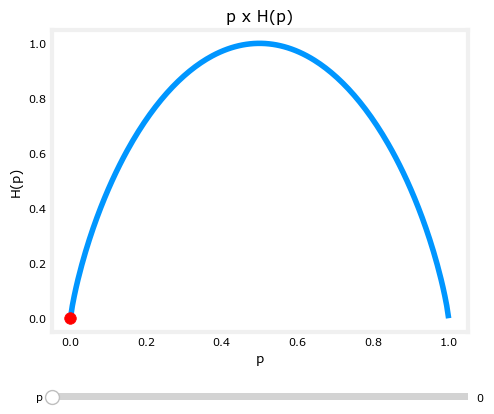

In [2]:
# %matplotlib widget
_ = plot_entropy()

## Classification decision tree (cat or not)

* Uses information gain (change in entropy for classification trees) to determine order of decision nodes. On each node, we compute the information gain for each feature, then split the node on the feature with the higher information gain, by comparing the entropy of the node with the weighted entropy in the two splitted nodes.
* Uses one-hot encoding to transform all features into binary yes/no features.

### Build the dataset

In [3]:
# features: pointy ears? + round face shape? + whiskers present?
X_train = np.array([
    [1, 1, 1],
    [0, 0, 1],
    [0, 1, 0],
    [1, 0, 1],
    [1, 1, 1],
    [1, 1, 0],
    [0, 0, 0],
    [1, 1, 0],
    [0, 1, 0],
    [0, 1, 0]])

y_train = np.array([1, 1, 0, 0, 1, 1, 0, 1, 0, 0])

print(f"There are {X_train.shape[0]} training examples with {X_train.shape[1]} features each.")

There are 10 training examples with 3 features each.


In [4]:
# inspect the first training example
print(X_train[0])

X_train[0]

[1 1 1]


array([1, 1, 1])

### Calculate information gain to determine order of decision nodes

Steps:
* Split the training examples based on their features. Use the training indices to reference the different examples.
* Calculate weighted entropy of the resulting (post-split) pair.
* Calculate information gain of the split: entropy before the split - weighted entropy after the split

In [5]:
def entropy(p):
    if p == 0 or p == 1:
        return 0
    else:
        return -p * np.log2(p) - (1- p)*np.log2(1 - p)

# Entropy = 1 when the split of elements is 50/50. That is the least pure situation possible.
# Entropy = 0 when the selection is completely pure.
assert(entropy(0.5) == 1)
assert(entropy(1.0) == 0)

In [6]:
# Places the indices of the training examples into two groups (left and right) based on whether they have a positive value for the given feature
def split_indices(X, index_feature):
    """Given a dataset and a index feature, return two lists for the two split nodes, the left node has the animals that have 
    that feature = 1 and the right node those that have the feature = 0.
    
    index feature = 0 => ear shape  ... in a training example, index 0 is the feature for ear shape... pointy ears: yes/no
    index feature = 1 => face shape
    index feature = 2 => whiskers
    """
    
    left_indices = []
    right_indices = []
    for i,x in enumerate(X):

        # if the feature is 'hot'/true/1... then it goes in left group
        if x[index_feature] == 1:
            left_indices.append(i)

        # else it goes in right group
        else:
            right_indices.append(i)
            
    return left_indices, right_indices

In [7]:
# Takes the split datasets and returns the weighted entropy for the pair, which is the 2nd term in the calculation of information loss.
def weighted_entropy(X,y,left_indices,right_indices):
    """
    This function takes the splitted dataset, the indices we chose to split and returns the weighted entropy.
    """
    
    w_left = len(left_indices)/len(X)
    w_right = len(right_indices)/len(X)
    p_left = sum(y[left_indices])/len(left_indices)
    p_right = sum(y[right_indices])/len(right_indices)
    
    weighted_entropy = w_left * entropy(p_left) + w_right * entropy(p_right)
    
    return weighted_entropy

In [8]:
# Calculates the information gain of adding a decision node: entropy before the split - weighted entropy after the split
def information_gain(X, y, left_indices, right_indices):
    """
    Here, X has the elements in the node and y is theirs respectives classes
    """
    
    p_node = sum(y)/len(y)
    h_node = entropy(p_node)
    w_entropy = weighted_entropy(X,y,left_indices,right_indices)
    
    return h_node - w_entropy

In [9]:
# Example

# Split all training examples based on the 0th feature (ear shape)
left_indices, right_indices = split_indices(X_train, 0)
print(f"left side: {left_indices}")
print(f"right side: {right_indices}")

left side: [0, 3, 4, 5, 7]
right side: [1, 2, 6, 8, 9]


In [10]:
# Calculate weighted entropy of the above splitting
weighted_entropy(X_train, y_train, left_indices, right_indices)

# weighted_entropy = weighted_entropy(X_train, y_train, left_indices, right_indices)
# print(f"weighted entropy of this split: {weighted_entropy}")

np.float64(0.7219280948873623)

In [11]:
# Calculate the information gain: entropy before the split - weighted entropy after the split
information_gain(X_train, y_train, left_indices, right_indices)

np.float64(0.2780719051126377)

#### Compute the information gain for each feature to determine which one to add next

The information gain for ear shape is the highest so that is the feature that we should use for the first decision node.

In [12]:
for i, feature_name in enumerate(['Ear Shape', 'Face Shape', 'Whiskers']):
    left_indices, right_indices = split_indices(X_train, i)
    i_gain = information_gain(X_train, y_train, left_indices, right_indices)
    print(f"Feature: {feature_name}, information gain if we split the root node using this feature: {i_gain:.2f}")
    

Feature: Ear Shape, information gain if we split the root node using this feature: 0.28
Feature: Face Shape, information gain if we split the root node using this feature: 0.03
Feature: Whiskers, information gain if we split the root node using this feature: 0.12


#### Build tree recursively (using library)

The process is recursive, which means we must perform these calculations for each node until we meet a stopping criteria:
* If the tree depth after splitting exceeds a threshold
* If the resulting node has only 1 class
* If the information gain of splitting is below a threshold

In [15]:
tree = []
build_tree_recursive(X_train, y_train, [0,1,2,3,4,5,6,7,8,9], "Root", max_depth=1, current_depth=0, tree = tree)
# generate_tree_viz([0,1,2,3,4,5,6,7,8,9], y_train, tree)

 Depth 0, Root: Split on feature: 0
 - Left leaf node with indices [0, 3, 4, 5, 7]
 - Right leaf node with indices [1, 2, 6, 8, 9]


[([0, 3, 4, 5, 7], [1, 2, 6, 8, 9], 0)]

In [16]:
# final tree
tree = []
build_tree_recursive(X_train, y_train, [0,1,2,3,4,5,6,7,8,9], "Root", max_depth=2, current_depth=0, tree = tree)
# generate_tree_viz([0,1,2,3,4,5,6,7,8,9], y_train, tree)

 Depth 0, Root: Split on feature: 0
- Depth 1, Left: Split on feature: 1
  -- Left leaf node with indices [0, 4, 5, 7]
  -- Right leaf node with indices [3]
- Depth 1, Right: Split on feature: 2
  -- Left leaf node with indices [1]
  -- Right leaf node with indices [2, 6, 8, 9]


[([0, 3, 4, 5, 7], [1, 2, 6, 8, 9], 0),
 ([0, 4, 5, 7], [3], 1),
 ([1], [2, 6, 8, 9], 2)]